In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv

In [2]:
file_path = "../data/01_stimuli/empatheticdialogues/test.csv"
column_names = [
    "conv_id",
    "utterance_idx",
    "context",
    "prompt",
    "speaker_idx",
    "utterance",
    "selfeval",
    "tags",
    "empathetic_responses" # New column added
]

emp_diag_test = pd.read_csv(
    file_path,
    names=column_names,
    skiprows=1
)

print(f'Columns: {emp_diag_test.columns}\n Number of rows: {len(emp_diag_test)}')

Columns: Index(['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx',
       'utterance', 'selfeval', 'tags', 'empathetic_responses'],
      dtype='object')
 Number of rows: 10943


Added a new column because half of the utterances had an extra column that was not explicitly stated in the first row headers. From the original paper I a asume that it's the new empathetic response generated.

In [3]:
emp_diag_test.head()

,conv_id,utterance_idx,context,prompt,speaker_idx,utterance,selfeval,tags,empathetic_responses
0,hit:0_conv:0,1,guilty,I felt guilty when I was driving home one nigh...,0,Yeah about 10 years ago I had a horrifying exp...,2|2|5_5|5|5,NaN,NaN
1,hit:0_conv:0,2,guilty,I felt guilty when I was driving home one nigh...,1,Did you suffer any injuries?,2|2|5_5|5|5,NaN,I hope it goes well! If it makes you feel any ...
2,hit:0_conv:0,3,guilty,I felt guilty when I was driving home one nigh...,0,No I wasn't hit. It turned out they were drunk...,2|2|5_5|5|5,NaN,NaN
3,hit:0_conv:0,4,guilty,I felt guilty when I was driving home one nigh...,1,Why did you feel guilty? People really shouldn...,2|2|5_5|5|5,NaN,Yep! or if you're house will be hit. Many pos...
4,hit:0_conv:0,5,guilty,I felt guilty when I was driving home one nigh...,0,I don't know I was new to driving and hadn't e...,2|2|5_5|5|5,NaN,NaN


In [4]:
# Cleaning the '_comma_' placeholder in text columns
text_columns = ['context', 'prompt', 'utterance', 'empathetic_responses']

for col in text_columns:
    emp_diag_test[col] = emp_diag_test[col].str.replace('_comma_', ',', regex=False).fillna('')

In [5]:
emp_diag_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10943 entries, 0 to 10942
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   conv_id               10943 non-null  object
 1   utterance_idx         10943 non-null  int64 
 2   context               10943 non-null  object
 3   prompt                10943 non-null  object
 4   speaker_idx           10943 non-null  int64 
 5   utterance             10943 non-null  object
 6   selfeval              10939 non-null  object
 7   tags                  75 non-null     object
 8   empathetic_responses  10943 non-null  object
dtypes: int64(2), object(7)
memory usage: 769.6+ KB


In [6]:
emp_diag_test.describe(include="O")

,conv_id,context,prompt,utterance,selfeval,tags,empathetic_responses
count,10943,10943,10943,10943,10939,75,10943
unique,2542,32,2537,10873,255,5,5243
top,hit:12110_conv:24220,surprised,when you expect more you have been disapponted...,5,5|5|5_5|5|5,<UNIGRAM>,
freq,8,557,10,9,6086,30,5701


In [7]:
emp_diag_test.describe(include=np.number)

,utterance_idx,speaker_idx
count,10943.000000,10943.000000
mean,2.716166,316.473819
std,1.347514,205.355992
min,1.000000,0.000000
25%,2.000000,138.000000
50%,3.000000,301.000000
75%,4.000000,450.000000
max,8.000000,852.000000


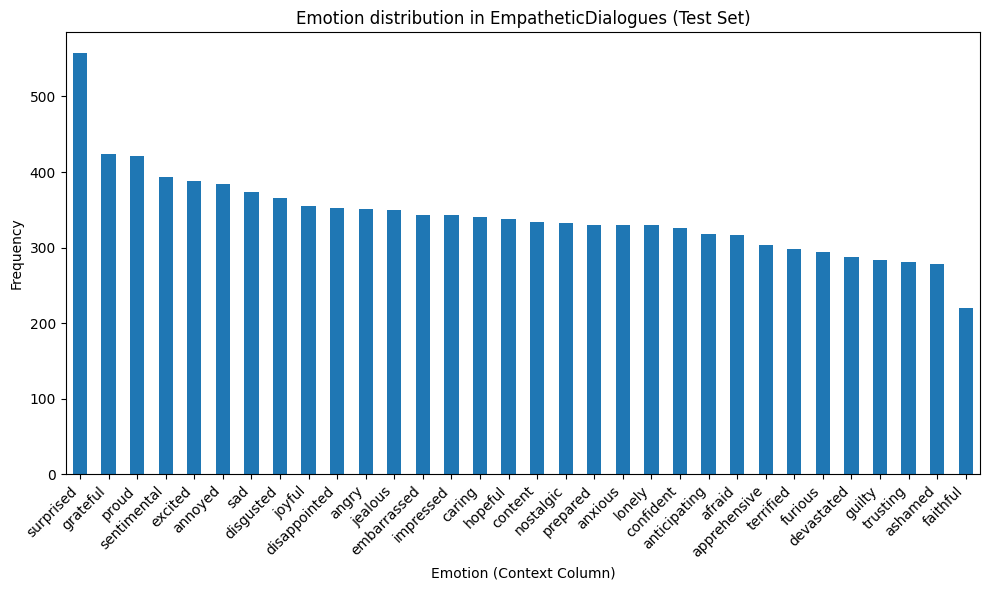

In [8]:
emotion_distribution = emp_diag_test["context"].value_counts()

emotion_distribution.plot(kind="bar", figsize=(10, 6), title="Emotion distribution in EmpatheticDialogues (Test Set)")
plt.ylabel("Frequency")
plt.xlabel("Emotion (Context Column)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
n_conv = emp_diag_test["conv_id"].nunique()
print(f'Unique conversations n: {n_conv}')

Unique conversations n: 2542


There are 2542 conversations, and the distribution of emotions seems very homogeneous through them. But in this first stage we only care about the first utterance (static stimulus, not conversational). What is the distribution of emotions over all the first utterances?

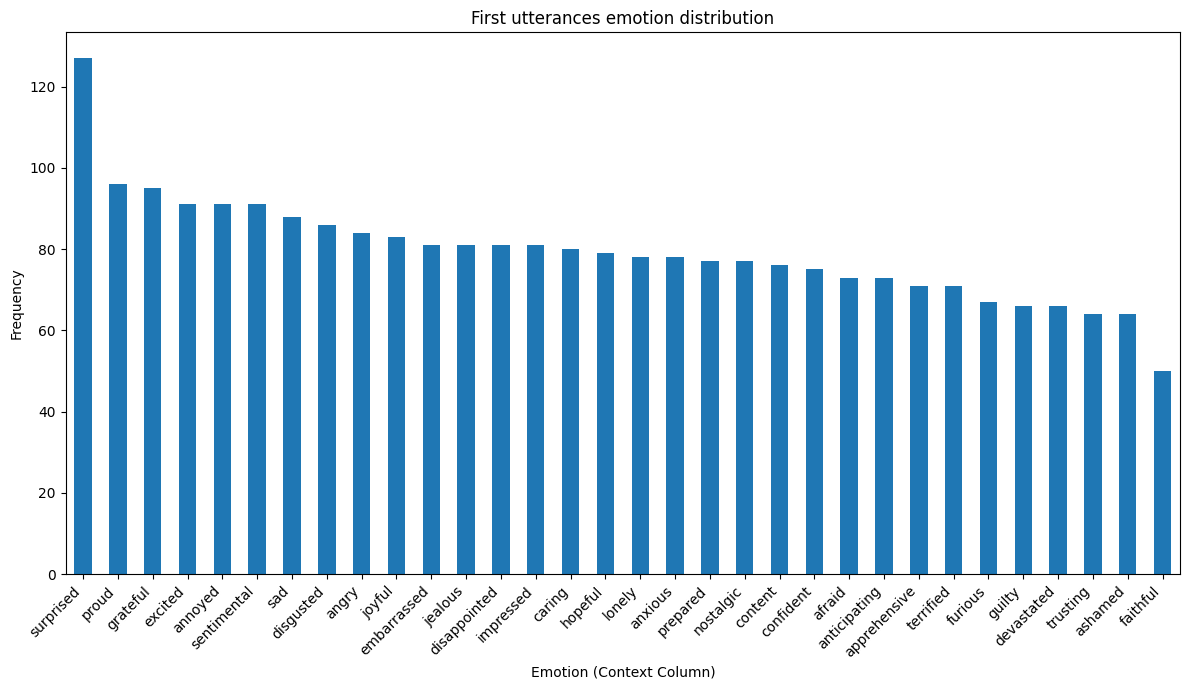

In [10]:
first_utterances_df = emp_diag_test[emp_diag_test["utterance_idx"] == 1].copy()

emotion_counts_first_utterances = first_utterances_df["context"].value_counts()

emotion_counts_first_utterances.plot(kind='bar', figsize=(12, 7), title="First utterances emotion distribution")
plt.ylabel("Frequency")
plt.xlabel("Emotion (Context Column)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The distribution is the same, so the conversations are labeled and not the utterances. This information is in the original paper, but this exploration serves as a corroboration/sanity check of that. 

In [11]:
for i, row in first_utterances_df.iloc[0:5].iterrows():
    print(f'{row.context}\n{row.utterance} \n')

guilty
Yeah about 10 years ago I had a horrifying experience. It was 100% their fault but they hit the water barrels and survived. They had no injuries but they almost ran me off the road. 

caring
Well, can you tell me about your experience? I think we swapped places 

lonely
I there, dont know what to do, jst broke up with my girlfirned, we were 8 years together 

excited
I couldn't wait to go to the concert. 

sad
I'm so sad because i've read an article about a newborn girl who died because her parents didn't believe in medication and doctors 



In [12]:
for i, row in first_utterances_df.iloc[0:5].iterrows():
    print(f'{row.context}\n{row.prompt} \n')

guilty
I felt guilty when I was driving home one night and a person tried to fly into my lane, and didn't see me. I honked and they swerved back into their lane, slammed on their brakes, and hit the water cones. 

caring
My mother stopped by my house one day and said she saw 3 dogs on the road, down from our house. They were starving, with ribs showing, and it was a mother dog and her two small puppies. Of course, my daughter wanted to bring them to our house, so we could feed and help them. We did, and my heart went out to them, as they were so sweet, but really were in a bad shape. 

lonely
I just broke up with my girlfriend, we were together for 8 years, i feel so empty. 

excited
I received concert tickets for Christmas. 

sad
i've read an article about a little newborn babygirl. She died because she was premature and she had problems breathing on her own when she was born but parents didn't take her to the hospital because they don't believe in medication 



Prompts are better stimuli than first utterances, so I'm saving them in a csv so I can use them to generate outputs.

In [13]:
prompt_context_pairs = emp_diag_test[["prompt", "context"]]

unique_prompts_df = prompt_context_pairs.drop_duplicates().reset_index(drop=True)

unique_prompts_df.head(10)

,prompt,context
0,I felt guilty when I was driving home one nigh...,guilty
1,My mother stopped by my house one day and said...,caring
2,"I just broke up with my girlfriend, we were to...",lonely
3,I received concert tickets for Christmas.,excited
4,i've read an article about a little newborn ba...,sad
5,my friend's baby hurt himself yesterday i was ...,caring
6,i really hope my husband finds a full time job...,hopeful
7,some guys shot my neighbour and ran into the w...,angry
8,I'm going to see my parents soon!,joyful
9,I felt very angry when a co-worker of mine pre...,angry


In [14]:
# Handling quotes in prompts
unique_prompts_df["prompt"] = unique_prompts_df["prompt"].astype(str)
unique_prompts_df["prompt"] = unique_prompts_df["prompt"].str.strip('"')

unique_prompts_df.rename(columns={"prompt": "situation", "context": "emotion"}, inplace=True)

unique_prompts_df.to_csv("../data/01_stimuli/empatheticdialogues/test_unique_prompts.csv",
                         index=False,
                         quoting=csv.QUOTE_NONNUMERIC)